In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [49]:
path = r'..\Data\HourlyTransformedData\hourly_energy_data_for_YWNC-203.csv'

df = pd.read_csv(
    path,
    index_col=0,        # first column is the index
    parse_dates=True   # parse it as datetime
)

C:\Users\devan\AppData\Local\Temp\ipykernel_15112\2191208957.py:3: UserWarning:

Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [50]:
df.shape

(3820, 25)

In [51]:
df.tail()

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,long_gap_flag,hour,day,weekday,hour_sin,hour_cos,weekday_sin,...,is_7to15_shift,kwh_roll_2,kwh_roll_24,power_proxy,time_since_gap,time_since_gap_log,is_sunday,low_activity_detected,spike_detected,HOURLY_KWH_capped
2025-12-28 20:00:00,0.156,0.555391,240.225174,False,20,28,6,-0.866025,0.500000,-0.781831,...,0,0.1550,1.000333,133.418973,463,6.139885,1,1,0,0.156
2025-12-28 21:00:00,0.155,0.555696,240.178044,False,21,28,6,-0.707107,0.707107,-0.781831,...,0,0.1555,0.951292,133.465894,464,6.142037,1,1,0,0.155
2025-12-28 22:00:00,0.148,0.555273,240.151318,False,22,28,6,-0.500000,0.866025,-0.781831,...,0,0.1515,0.901625,133.349477,465,6.144186,1,1,0,0.155
2025-12-28 23:00:00,0.156,0.555522,240.134826,False,23,28,6,-0.258819,0.965926,-0.781831,...,0,0.1520,0.850000,133.400116,466,6.146329,1,1,0,0.156
2025-12-29 00:00:00,0.155,0.555739,240.099565,False,0,29,0,0.000000,1.000000,0.000000,...,0,0.1555,0.801667,133.432724,467,6.148468,0,1,0,0.155


In [52]:
df.dropna(inplace = True)

In [53]:
df.shape

(3652, 25)

In [54]:
df.columns

Index(['HOURLY_KWH', 'AVG_CURRENT', 'AVG_V_LN', 'long_gap_flag', 'hour', 'day',
       'weekday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
       'kwh_lag_1', 'kwh_lag_8', 'kwh_lag_24', 'kwh_lag_168', 'is_7to15_shift',
       'kwh_roll_2', 'kwh_roll_24', 'power_proxy', 'time_since_gap',
       'time_since_gap_log', 'is_sunday', 'low_activity_detected',
       'spike_detected', 'HOURLY_KWH_capped'],
      dtype='object')

In [55]:
# Spliting data in target column and independent column




linear_feature_cols = ["power_proxy", "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "kwh_lag_1", "kwh_lag_8", 
                       "kwh_lag_24", "is_7to15_shift", "is_sunday", "time_since_gap_log"]
linear_X = df[linear_feature_cols]




rf_feature_cols = ["AVG_CURRENT", "AVG_V_LN", "power_proxy", "hour", "weekday", "hour_sin", "hour_cos", "weekday_sin", 
                   "weekday_cos", "kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168", "kwh_roll_2", "kwh_roll_24", 
                   "is_7to15_shift", "is_sunday", "time_since_gap", "low_activity_detected", "spike_detected"]

rf_X = df[rf_feature_cols]


y = df['HOURLY_KWH_capped']
target_col = 'HOURLY_KWH_capped'

In [56]:
# Train Test Spitt
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train[linear_feature_cols]
X_test = test[linear_feature_cols]
y_train = train[target_col]
y_test = test[target_col]

### Linear Regression Model

In [57]:
## Applying Linear Regression Model

linear_regression_model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None)

linear_regression_model.fit(X_train, y_train)

y_pred = linear_regression_model.predict(X_test)


In [58]:
print(f"Value of coefficients:- {linear_regression_model.coef_}")
print(f"Value of Intercept:- {linear_regression_model.intercept_}")
print("Train R²:", linear_regression_model.score(X_train, y_train))
print("Test R² :", linear_regression_model.score(X_test, y_test))

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE:- {rmse}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean absolute error:- {mae}")



cv_r2 = cross_val_score(
    linear_regression_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())


Value of coefficients:- [ 0.00065566 -0.00736814  0.04800343  0.0041691   0.02926291  0.44146931
  0.05725458  0.04509027  0.08172966 -0.07318839  0.0077053 ]
Value of Intercept:- -0.1470001762241282
Train R²: 0.893332981849065
Test R² : 0.021802945663009665
RMSE:- 0.4883167750188336
Mean absolute error:- 0.11911912958205857
CV R² scores: [0.48612997 0.71621731 0.89609341 0.94498703 0.87794487]
Mean CV R²: 0.7842745167458218


In [59]:
# Compute residuals
residuals = y_test - y_pred

# Create DataFrame for Plotly
res_df = pd.DataFrame({
    "Predicted": y_pred,
    "Residuals": residuals
}, index=y_test.index)

# Plot
fig = px.scatter(
    res_df,
    x="Predicted",
    y="Residuals",
    title="Residuals vs Predicted",
    labels={
        "Predicted": "Predicted Energy",
        "Residuals": "Residual (Actual - Predicted)"
    },
    opacity=0.7
)

# Add horizontal zero line
fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.show()

In [60]:
# Convert to DataFrame
res_df = pd.DataFrame({
    "Residuals": residuals
})

# Plot interactive histogram
fig = px.histogram(
    res_df,
    x="Residuals",
    nbins=50,
    title="Residual Distribution",
    labels={"Residuals": "Residual (Actual - Predicted)"},
    opacity=0.75
)

# Optional: add mean & zero reference lines
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.add_vline(
    x=residuals.mean(),
    line_dash="dot",
    line_color="green",
    annotation_text="Mean",
    annotation_position="top"
)

fig.show()


In [61]:
# Create DataFrame
ap_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}, index=y_test.index)

# Interactive scatter plot
fig = px.scatter(
    ap_df,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted",
    labels={
        "Actual": "Actual Value",
        "Predicted": "Predicted Value"
    },
    opacity=0.7
)

# Add perfect prediction line (y = x)
min_val = min(ap_df.min())
max_val = max(ap_df.max())
fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash", color="red"),
)

fig.show()

In [62]:
# Ensure data is aligned
ts_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}, index=y_test.index).sort_index()

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Actual"],
    mode="lines",
    name="Actual",
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Predicted"],
    mode="lines",
    name="Predicted",
    line=dict(width=2, dash="dash"),
    opacity=0.85
))

fig.update_layout(
    title="Actual vs Predicted Energy Over Time",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white"
)

fig.show()

In [63]:
y_full_pred = linear_regression_model.predict(linear_X)

# Create DataFrame
results_full_df = pd.DataFrame(
    {
        "Actual": y,
        "Predicted": y_full_pred
    },
    index=y.index  # ensure your time index is preserved
)

# Compute residual
results_full_df["Residual(Difference)"] = results_full_df["Actual"] - results_full_df["Predicted"]

# Sort by time
results_full_df = results_full_df.sort_index()

results_full_df.head()

,Actual,Predicted,Residual(Difference)
2025-07-29 21:00:00,2.267,2.340669,-0.073669
2025-07-29 22:00:00,2.267,2.459962,-0.192962
2025-07-29 23:00:00,2.267,2.055630,0.211370
2025-07-30 00:00:00,2.267,2.205869,0.061131
2025-07-30 01:00:00,2.267,2.107843,0.159157


##### Predecting energy for the next day

In [64]:
# Identify last timestamp
last_time = linear_X.index.max()
print("Last timestamp:", last_time)


# Create next day hourly timestamps  (FIXED: 'H' → 'h')
next_day_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,  # 24 hours
    freq='h'
)

# Create a new DataFrame for next day
next_day_X = pd.DataFrame(index=next_day_times)
hour = next_day_X.index.hour
weekday = next_day_X.index.weekday

next_day_X["power_proxy"] = (
    rf_X["AVG_CURRENT"].iloc[-1] *
    rf_X["AVG_V_LN"].iloc[-1]
)

next_day_X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
next_day_X["hour_cos"] = np.cos(2 * np.pi * hour / 24)

next_day_X["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
next_day_X["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

next_day_X["kwh_lag_1"]  = y.iloc[-1]
next_day_X["kwh_lag_8"]  = y.iloc[-8]
next_day_X["kwh_lag_24"] = y.iloc[-24]

next_day_X["is_7to15_shift"] = (
    (hour >= 7) & (hour <= 15)
).astype(int)

next_day_X["is_sunday"] = (weekday == 6).astype(int)

time_since_gap = rf_X["time_since_gap"].iloc[-1] + 1
next_day_X["time_since_gap_log"] = np.log1p(time_since_gap)



# -----------------------------
# PREDICTION
# -----------------------------
next_day_pred = linear_regression_model.predict(next_day_X)


# -----------------------------
# PLOTTING
# -----------------------------
forecast_df = pd.DataFrame(
    {"Predicted": next_day_pred},
    index=next_day_X.index
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines+markers",
    name="Predicted Next Day",
    line=dict(color="blue", width=2)
))

fig.update_layout(
    title="Next Day Hourly Energy Prediction",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()


Last timestamp: 2025-12-29 00:00:00


In [65]:
forecast_df.head()

,Predicted
2025-12-29 01:00:00,0.204072
2025-12-29 02:00:00,0.197499
2025-12-29 03:00:00,0.188344
2025-12-29 04:00:00,0.177232
2025-12-29 05:00:00,0.164918


### Random Forest

In [66]:
# Train Test Spitt
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train[rf_feature_cols]
X_test = test[rf_feature_cols]
y_train = train[target_col]
y_test = test[target_col]

In [87]:
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(rf_X):
    X_train, X_test = rf_X.iloc[train_idx], rf_X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [88]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],      # Number of trees
    "max_depth": [None, 5, 10, 20],           # Max depth of each tree
    "min_samples_split": [2, 5, 10],          # Minimum samples to split a node
    "min_samples_leaf": [1, 2, 4],            # Minimum samples in a leaf node
    "max_features": ["sqrt", "log2", None]  # Number of features to consider at split
}

In [89]:
# Use TimeSeriesSplit for energy/time-series data
tscv = TimeSeriesSplit(n_splits=5)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,                # Number of random combinations to try
    scoring='neg_root_mean_squared_error',  # minimize RMSE
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1                  # Use all CPUs
)

# Fit
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [90]:
print("Best Parameters:", rf_random.best_params_)
print("Best CV Score (RMSE):", -rf_random.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Best CV Score (RMSE): 0.12394004505648668


In [91]:
# y_pred on test and train
y_test_pred = rf_random.predict(X_test)
y_train_pred = rf_random.predict(X_train)

# Evaluate R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

# RMSE
rmse = root_mean_squared_error(y_test, y_test_pred)
print(f"RMSE: {rmse:.4f}")

# MAE
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Mean Absolute Error: {mae:.4f}")

# Cross-Validation (R²)
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=24*7,
    gap=24
)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {fold+1}: train={len(train_idx)}, test={len(test_idx)}")
    
cv_r2 = cross_val_score(
    rf_random.best_estimator_,  # use best RF from tuning
    X_train,
    y_train,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

print("CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())

Train R²: 0.9977176004153651
Test R² : 0.9920618235110092
RMSE: 0.0400
Mean Absolute Error: 0.0131
Fold 1: train=2180, test=168
Fold 2: train=2348, test=168
Fold 3: train=2516, test=168
Fold 4: train=2684, test=168
Fold 5: train=2852, test=168
CV R² scores: [0.99626263 0.99538395 0.99378179 0.99395049 0.99701103]
Mean CV R²: 0.9952779781647008


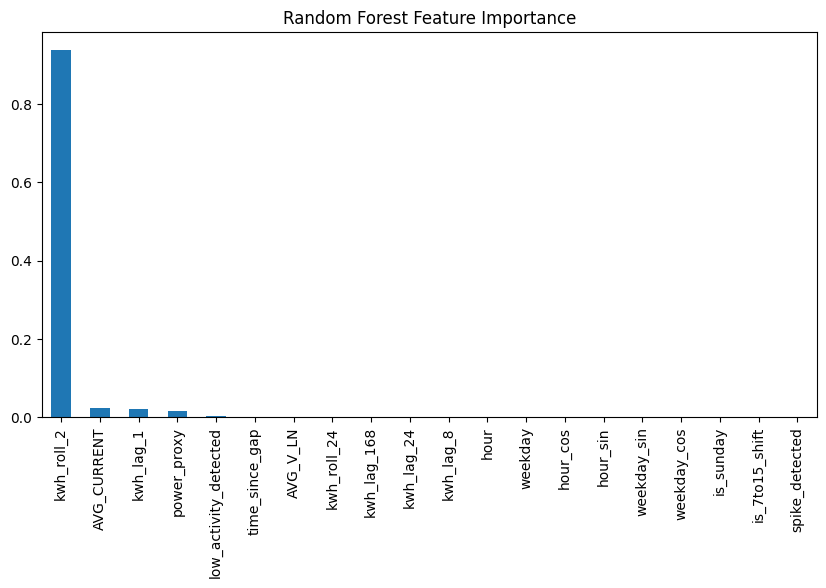

In [92]:
plt.figure(figsize=(7, 3))
feat_imp = pd.Series(rf_random.best_estimator_.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', title="Random Forest Feature Importance", figsize=(10,5))
plt.show()

In [93]:
# Compute residuals
residuals = y_test - y_test_pred

# Create DataFrame for Plotly
res_df = pd.DataFrame({
    "Predicted": y_test_pred,
    "Residuals": residuals
}, index=y_test.index)

# Plot
fig = px.scatter(
    res_df,
    x="Predicted",
    y="Residuals",
    title="Residuals vs Predicted",
    labels={
        "Predicted": "Predicted Energy",
        "Residuals": "Residual (Actual - Predicted)"
    },
    opacity=0.7
)

# Add horizontal zero line
fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.show()

In [94]:
# Convert to DataFrame
res_df = pd.DataFrame({
    "Residuals": residuals
})

# Plot interactive histogram
fig = px.histogram(
    res_df,
    x="Residuals",
    nbins=50,
    title="Residual Distribution",
    labels={"Residuals": "Residual (Actual - Predicted)"},
    opacity=0.75
)

# Optional: add mean & zero reference lines
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.add_vline(
    x=residuals.mean(),
    line_dash="dot",
    line_color="green",
    annotation_text="Mean",
    annotation_position="top"
)

fig.show()


In [95]:
# Create DataFrame
ap_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
}, index=y_test.index)

# Interactive scatter plot
fig = px.scatter(
    ap_df,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted",
    labels={
        "Actual": "Actual Value",
        "Predicted": "Predicted Value"
    },
    opacity=0.7
)

# Add perfect prediction line (y = x)
min_val = min(ap_df.min())
max_val = max(ap_df.max())
fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash", color="red"),
)

fig.show()

In [96]:
# Ensure data is aligned
ts_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
}, index=y_test.index).sort_index()

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Actual"],
    mode="lines",
    name="Actual",
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=ts_df.index,
    y=ts_df["Predicted"],
    mode="lines",
    name="Predicted",
    line=dict(width=2, dash="dash"),
    opacity=0.85
))

fig.update_layout(
    title="Actual vs Predicted Energy Over Time",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white"
)

fig.show()

In [97]:
# -----------------------------
# 1. Identify last timestamp
# -----------------------------
last_time = rf_X.index.max()
print("Last timestamp:", last_time)

# -----------------------------
# 2. Create next day hourly timestamps
# -----------------------------
next_day_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

next_day_X = pd.DataFrame(index=next_day_times)
next_day_X["hour"] = next_day_X.index.hour
next_day_X["weekday"] = next_day_X.index.weekday

hour = next_day_X["hour"]
weekday = next_day_X["weekday"]

# -----------------------------
# 3. Prepare historical stats (PAST DATA ONLY)
# -----------------------------
hist_df = rf_X.loc[rf_X.index < next_day_times[0]].copy()
hist_df["hour"] = hist_df.index.hour
hist_df["weekday"] = hist_df.index.weekday

# Weekday + hour mean
weekday_hour_means = (
    hist_df
    .groupby(["weekday", "hour"])[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

# Hour-only fallback
hour_means = hist_df.groupby("hour")[["AVG_CURRENT", "AVG_V_LN"]].mean()

# -----------------------------
# 4. Populate AVG_CURRENT & AVG_V_LN (CORRECT WAY)
# -----------------------------
next_day_X = next_day_X.merge(
    weekday_hour_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Fallbacks
for col in ["AVG_CURRENT", "AVG_V_LN"]:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_means[col])
    )

next_day_X[["AVG_CURRENT", "AVG_V_LN"]] = (
    next_day_X[["AVG_CURRENT", "AVG_V_LN"]]
    .fillna(hist_df[["AVG_CURRENT", "AVG_V_LN"]].mean())
)

# -----------------------------
# 5. Power proxy
# -----------------------------
next_day_X["power_proxy"] = (
    next_day_X["AVG_CURRENT"] * next_day_X["AVG_V_LN"]
)

# -----------------------------
# 6. Cyclical time encoding
# -----------------------------
next_day_X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
next_day_X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
next_day_X["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
next_day_X["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

# -----------------------------
# 7. Lag features (target-based)
# -----------------------------
hist_df["kwh_lag_1"]   = y.shift(1)
hist_df["kwh_lag_8"]   = y.shift(8)
hist_df["kwh_lag_24"]  = y.shift(24)
hist_df["kwh_lag_168"] = y.shift(168)

lag_cols = ["kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168"]
weekday_hour_lag_means = (
    hist_df
    .groupby(["weekday", "hour"])[lag_cols]
    .mean()
)
hour_lag_means = (
    hist_df
    .groupby("hour")[lag_cols]
    .mean()
)

next_day_X = next_day_X.merge(
    weekday_hour_lag_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)
# Fallback
for col in lag_cols:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_lag_means[col])
    )

next_day_X[lag_cols] = next_day_X[lag_cols].fillna(
    hist_df[lag_cols].mean()
)

# -----------------------------
# 8. Rolling statistics
# -----------------------------
hist_df["kwh_roll_2"] = y.rolling(2).mean()
hist_df["kwh_roll_24"] = y.rolling(24).mean()

roll_cols = ["kwh_roll_2", "kwh_roll_24"]
weekday_hour_roll_means = (
    hist_df
    .groupby(["weekday", "hour"])[roll_cols]
    .mean()
)
hour_roll_means = (
    hist_df
    .groupby("hour")[roll_cols]
    .mean()
)

next_day_X = next_day_X.merge(
    weekday_hour_roll_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Fallback
for col in roll_cols:
    next_day_X[col] = next_day_X[col].fillna(
        next_day_X["hour"].map(hour_roll_means[col])
    )

next_day_X[roll_cols] = next_day_X[roll_cols].fillna(
    hist_df[roll_cols].mean()
)

# -----------------------------
# 9. Shift & calendar features
# -----------------------------
next_day_X["is_7to15_shift"] = ((hour >= 7) & (hour <= 15)).astype(int)
next_day_X["is_sunday"] = (weekday == 6).astype(int)

# -----------------------------
# 10. Gap & activity flags
# -----------------------------
next_day_X["time_since_gap"] = rf_X["time_since_gap"].iloc[-1] + 1
next_day_X["low_activity_detected"] = rf_X["low_activity_detected"].iloc[-1]
next_day_X["spike_detected"] = rf_X["spike_detected"].iloc[-1]

# -----------------------------
# 11. Align feature order
# -----------------------------
next_day_X = next_day_X[rf_feature_cols]

# -----------------------------
# 12. Predict (Random Forest)
# -----------------------------
next_day_pred = rf_random.predict(next_day_X)

# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df = pd.DataFrame(
    {"Predicted": next_day_pred},
    index=next_day_X.index
)

# -----------------------------
# 14. Plot
# -----------------------------
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines+markers",
    name="Predicted Next Day",
    line=dict(color="green", width=2)
))

fig.update_layout(
    title="Next Day Hourly Energy Prediction (Random Forest)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()


Last timestamp: 2025-12-29 00:00:00


### NEXT 7 DAYS (168 HOURS) FORECAST

In [98]:
# -----------------------------
# 1. Identify last timestamp
# -----------------------------
last_time = rf_X.index.max()
print("Last timestamp:", last_time)

# -----------------------------
# 2. Create next 7 days hourly timestamps
# -----------------------------
HORIZON = 24 * 7  # 168 hours

next_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=HORIZON,
    freq="h"
)

next_X = pd.DataFrame(index=next_times)
next_X["hour"] = next_X.index.hour
next_X["weekday"] = next_X.index.weekday

hour = next_X["hour"]
weekday = next_X["weekday"]

# -----------------------------
# 3. Prepare historical stats (PAST DATA ONLY)
# -----------------------------
hist_df = rf_X.loc[rf_X.index < next_times[0]].copy()
hist_df["hour"] = hist_df.index.hour
hist_df["weekday"] = hist_df.index.weekday

weekday_hour_means = (
    hist_df
    .groupby(["weekday", "hour"])[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

hour_means = (
    hist_df
    .groupby("hour")[["AVG_CURRENT", "AVG_V_LN"]]
    .mean()
)

# -----------------------------
# 4. Populate AVG_CURRENT & AVG_V_LN
# -----------------------------
next_X = next_X.merge(
    weekday_hour_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

for col in ["AVG_CURRENT", "AVG_V_LN"]:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_means[col])
    )

next_X[["AVG_CURRENT", "AVG_V_LN"]] = (
    next_X[["AVG_CURRENT", "AVG_V_LN"]]
    .fillna(hist_df[["AVG_CURRENT", "AVG_V_LN"]].mean())
)

# -----------------------------
# 5. Power proxy
# -----------------------------
next_X["power_proxy"] = (
    next_X["AVG_CURRENT"] * next_X["AVG_V_LN"]
)

# -----------------------------
# 6. Cyclical time encoding
# -----------------------------
next_X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
next_X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
next_X["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
next_X["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

# -----------------------------
# 7. Lag features (STATIC – LAST KNOWN)
# -----------------------------
hist_df["kwh_lag_1"]   = y.shift(1)
hist_df["kwh_lag_8"]   = y.shift(8)
hist_df["kwh_lag_24"]  = y.shift(24)
hist_df["kwh_lag_168"] = y.shift(168)

lag_cols  = ["kwh_lag_1", "kwh_lag_8", "kwh_lag_24", "kwh_lag_168"]
weekday_hour_lag_means = (
    hist_df
    .groupby(["weekday", "hour"])[lag_cols]
    .mean()
)
hour_lag_means = (
    hist_df
    .groupby("hour")[lag_cols]
    .mean()
)

# Lag features
next_X = next_X.merge(
    weekday_hour_lag_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Lag fallbacks
for col in lag_cols:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_lag_means[col])
    )

next_X[lag_cols] = next_X[lag_cols].fillna(
    hist_df[lag_cols].mean()
)

# -----------------------------
# 8. Rolling statistics
# -----------------------------
hist_df["kwh_roll_2"]  = y.rolling(2).mean()
hist_df["kwh_roll_24"] = y.rolling(24).mean()

roll_cols = ["kwh_roll_2", "kwh_roll_24"]
weekday_hour_roll_means = (
    hist_df
    .groupby(["weekday", "hour"])[roll_cols]
    .mean()
)
hour_roll_means = (
    hist_df
    .groupby("hour")[roll_cols]
    .mean()
)

# Rolling features
next_X = next_X.merge(
    weekday_hour_roll_means,
    left_on=["weekday", "hour"],
    right_index=True,
    how="left"
)

# Rolling fallbacks
for col in roll_cols:
    next_X[col] = next_X[col].fillna(
        next_X["hour"].map(hour_roll_means[col])
    )

next_X[roll_cols] = next_X[roll_cols].fillna(
    hist_df[roll_cols].mean()
)
# -----------------------------
# 9. Shift & calendar features
# -----------------------------
next_X["is_7to15_shift"] = ((hour >= 7) & (hour <= 15)).astype(int)
next_X["is_sunday"] = (weekday == 6).astype(int)

# -----------------------------
# 10. Gap & activity flags
# -----------------------------
next_X["time_since_gap"] = rf_X["time_since_gap"].iloc[-1] + 1
next_X["low_activity_detected"] = rf_X["low_activity_detected"].iloc[-1]
next_X["spike_detected"] = rf_X["spike_detected"].iloc[-1]

# -----------------------------
# 11. Align feature order
# -----------------------------
next_X = next_X[rf_feature_cols]

# -----------------------------
# 12. Predict (Random Forest)
# -----------------------------
next_pred = rf_random.predict(next_X)

# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df = pd.DataFrame(
    {"Predicted": next_pred},
    index=next_X.index
)


Last timestamp: 2025-12-29 00:00:00


In [99]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df["Predicted"],
    mode="lines",
    name="Next 7 Days Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Next 7 Days Hourly Energy Forecast (Random Forest)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()

In [100]:
daily_forecast = (
    forecast_df
    .resample("D")
    .sum()
)

fig.add_trace(go.Bar(
    x=daily_forecast.index,
    y=daily_forecast["Predicted"],
    name="Daily Energy (kWh)",
    opacity=0.6
))

In [101]:
forecast_df.head(24)

,Predicted
2025-12-29 01:00:00,0.292226
2025-12-29 02:00:00,0.293366
2025-12-29 03:00:00,0.272087
2025-12-29 04:00:00,0.263845
2025-12-29 05:00:00,0.263318
2025-12-29 06:00:00,0.284109
2025-12-29 07:00:00,0.697302
2025-12-29 08:00:00,1.225255
2025-12-29 09:00:00,1.282928
2025-12-29 10:00:00,1.171273


In [102]:
next_day_X.head()


,AVG_CURRENT,AVG_V_LN,power_proxy,hour,weekday,hour_sin,hour_cos,weekday_sin,weekday_cos,kwh_lag_1,kwh_lag_8,kwh_lag_24,kwh_lag_168,kwh_roll_2,kwh_roll_24,is_7to15_shift,is_sunday,time_since_gap,low_activity_detected,spike_detected
2025-12-29 01:00:00,0.958615,238.871800,228.986061,1,0,0.258819,0.965926,0.0,1.0,0.289106,0.422773,1.183916,0.297461,0.289892,0.804212,0,0,468,1,0
2025-12-29 02:00:00,0.972005,238.854386,232.167629,2,0,0.500000,0.866025,0.0,1.0,0.290677,0.407434,1.246916,0.304061,0.293820,0.764631,0,0,468,1,0
2025-12-29 03:00:00,0.857554,238.873095,204.846534,3,0,0.707107,0.707107,0.0,1.0,0.296963,0.346249,1.264773,0.266411,0.279035,0.722811,0,0,468,1,0
2025-12-29 04:00:00,0.849671,238.890265,202.978028,4,0,0.866025,0.500000,0.0,1.0,0.261106,0.330916,1.283820,0.226606,0.242151,0.678619,0,0,468,1,0
2025-12-29 05:00:00,0.852276,238.921976,203.627348,5,0,0.965926,0.258819,0.0,1.0,0.223196,0.349535,1.237005,0.264111,0.241056,0.637865,0,0,468,1,0
